# Time Series COVID-19 Deaths US Dataset Quality Assessment 
Based on the Weiskopf & Weng Framework

In [8]:
import pandas as pd
#import datetime when working with dates 
from datetime import datetime 
#import matplotlib for visuals
import matplotlib.pyplot as plt

#import data
covid19_deaths = pd.read_csv('time_series_covid19_deaths_US.csv')  
#show the first few rows of the data, to see what it looks like 
covid19_deaths.head(5)

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,230,232,232,232,232,232,232,232,232,232
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,724,726,726,726,726,726,726,726,727,727
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,103,103,103,103,103,103,103,103,103,103
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,109,109,109,109,109,109,109,109,109,109
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,261,261,261,261,261,261,261,261,261,261


In [2]:
#get to know the data 
covid19_deaths.info()
covid19_deaths.shape
covid19_deaths.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3342 entries, 0 to 3341
Columns: 1155 entries, UID to 3/9/23
dtypes: float64(3), int64(1146), object(6)
memory usage: 29.4+ MB


Index(['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State',
       'Country_Region', 'Lat', 'Long_',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1155)

### Completeness

In [3]:
#COMPLETENESS: missing data?

#overall completeness
#count every cell in the dataframe 
total_cells = covid19_deaths.size
#count how many cells are missing 
missing_cells = covid19_deaths.isnull().sum().sum()
#calculate % of data that is NOT missing 
completeness_rate = (1 - missing_cells / total_cells) * 100
print(f"Overall completeness (%): {completeness_rate}")

#check for values that were not assigned a county
#find rows where 'Admin2' contains Unassigned or Out of
#Reference: https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html
county_mask = covid19_deaths['Admin2'].str.contains('Unassigned|Out of', na = False) 
#use mask to filter data 
unassigned_county = covid19_deaths[county_mask]
print(f"Number of unassigned counties: {len(unassigned_county)}")

#missing Federal Information Processing Standard state codes (FIPS) codes
#Source: https://www.geocod.io/complete-guide-to-fips-codes/
#look for instances where FIPS is null
missing_FIPS = covid19_deaths['FIPS'].isnull().sum()
print(f"Rows missing FIPS: {missing_FIPS}")
#see which rows have missing FIPS
missing_fips_rows = covid19_deaths[covid19_deaths['FIPS'].isnull()]
print(missing_fips_rows[['Admin2', 'Province_State', 'FIPS']])
print()

#check if any key identifiers are missing from the columns
identifier_columns = ['Admin2', 'Province_State', 'Country_Region']
for column in identifier_columns:
    missing_identifiers = covid19_deaths[column].isnull().sum()
    print(f"Missing values in {column}: {missing_identifiers}")
    print()
#see which rows have no county name
missing_admin2 = covid19_deaths[covid19_deaths['Admin2'].isnull()]
print(missing_admin2[['Admin2', 'Province_State', 'FIPS']])

#check for missing coordinate values
missing_lat = covid19_deaths['Lat'].isnull().sum()
missing_long = covid19_deaths['Long_'].isnull().sum()
print(f"Missing latitude values: {missing_lat}")
print(f"Missing longitude values: {missing_long}")


Overall completeness (%): 99.99958549330184
Number of unassigned counties: 104
Rows missing FIPS: 10
                                         Admin2 Province_State  FIPS
1269                        Dukes and Nantucket  Massachusetts   NaN
1306     Federal Correctional Institution (FCI)       Michigan   NaN
1338  Michigan Department of Corrections (MDOC)       Michigan   NaN
1593                                Kansas City       Missouri   NaN
2956                                 Bear River           Utah   NaN
2961                               Central Utah           Utah   NaN
2980                             Southeast Utah           Utah   NaN
2981                             Southwest Utah           Utah   NaN
2984                                  TriCounty           Utah   NaN
2992                               Weber-Morgan           Utah   NaN

Missing values in Admin2: 6

Missing values in Province_State: 0

Missing values in Country_Region: 0

     Admin2            Province_Stat

### Visualizations for Completeness

<function matplotlib.pyplot.show(close=None, block=None)>

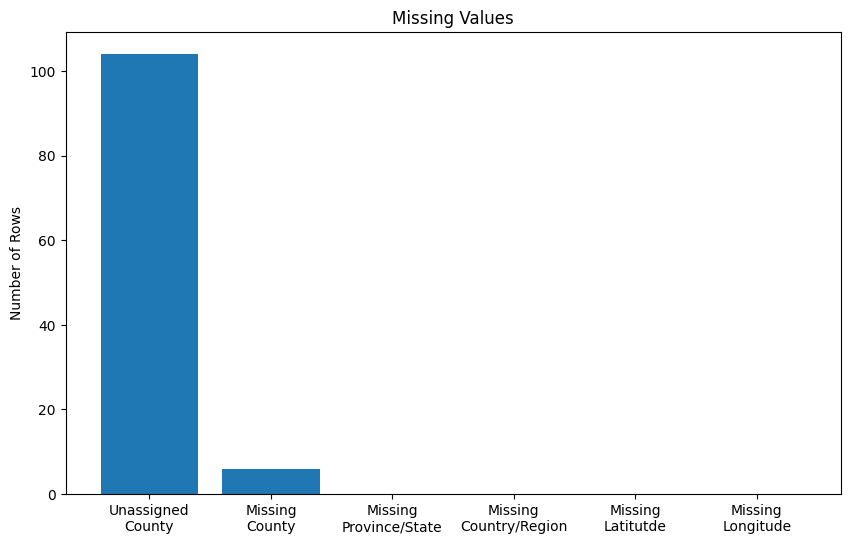

In [133]:
# Visualizations for Completeness

# Unassigned county, Missing county, FIPS, province_state, country_region
x = ['Unassigned\nCounty', 'Missing\nCounty', 'Missing\nProvince/State', 'Missing\nCountry/Region', 'Missing\nLatitutde', 'Missing\nLongitude']
y = [len(unassigned_county), len(missing_admin2), covid19_deaths['Province_State'].isnull().sum(), covid19_deaths['Country_Region'].isnull().sum(), missing_lat, missing_long]

plt.figure(figsize=(10, 6))
plt.bar(x,y)
plt.ylabel("Number of Rows")
plt.title("Missing Values")
plt.show

**Considerations for completeness:**
- Identifying unassigned counties: Do any counties need to be excluded from analysis? How does this affect state death totals if unassigned counties are not specified?
- Missing FIPS
- Missing Admin2: Should analysis be focused on states only, excluding territories? 

In [ ]:
#AI use disclosure:
#ChatGPT (OpenAI, GPT-5.3) was used to help create a Python example showing how to get geographic coordinate 
#information from U.S. Census TIGER/Line shapefiles using the GeoPandas library. The code showed how to read 
#the shapefile and calculate bounding box coordinates for each state. I reviewed the code and used it in my 
#work without changing the main steps.
#Accessed: March 8, 2026 
#Column      Meaning
#NAME        State or territory name
#minx        Westernmost longitude
#maxx        Easternmost longitude
#miny        Southernmost latitude
#maxy        Northernmost latitude
#install geopandas
!pip install geopandas
import geopandas as gpd
#continuation of LLM output walking through how to tise geopandas:
#read file
states = gpd.read_file('tl_2020_us_state.shp')
#get the bounding box for each state and territory
bounds = states.geometry.bounds
#add state names to the bounds
bounds['NAME'] = states['NAME'].values

#find the overall min and max values across all states and territories using 2020 states (and equivalent data)
#Reference: https://www.census.gov/cgi-bin/geo/shapefiles/index.php from the United States Census Bureau
min_lat = bounds['miny'].min()
max_lat = bounds['maxy'].max()
min_long = bounds['minx'].min()
max_long = bounds['maxx'].max()
print(f"Minimum latitude:  {min_lat}")
print(f"Maximum latitude:  {max_lat}")
print(f"Minimum longitude: {min_long}")
print(f"Maximum longitude: {max_long}")

### Correctness

In [66]:
#CORRECTNESS - values valid?

#latitude and longitude should be within the US and territories 
invalid_lat = covid19_deaths[(covid19_deaths['Lat'] < -14.6) | (covid19_deaths['Lat'] > 71.4)]
invalid_long = covid19_deaths[(covid19_deaths['Long_'] < -179.2) | (covid19_deaths['Long_'] > 179.9)]
print(f"Invalid latitude values: {len(invalid_lat)}")
print(f"Invalid longitude values: {len(invalid_long)}")

#check if each UID is unique/ duplicates
#Reference: https://pandas.pydata.org/docs/reference/api/pandas.Series.duplicated.html
duplicate_UID = covid19_deaths['UID'].duplicated().sum()
print(f"Non-unique UID's: {duplicate_UID}")

#check that all data is from the US 
#values that are not equal to US/USA/840 do not correspond with data from the US 
incorrect_iso2 = covid19_deaths[covid19_deaths['iso2'] != 'US']
incorrect_iso3 = covid19_deaths[covid19_deaths['iso3'] != 'USA']
incorrect_code3 = covid19_deaths[covid19_deaths['code3'] != 840]
#check country region is in US 
incorrect_country = covid19_deaths[covid19_deaths['Country_Region'] != 'US']
print(f"Incorrect iso2 values: {len(incorrect_iso2)}")
print(f"Incorrect iso3 values: {len(incorrect_iso3)}")
print(f"Incorrect code3 values: {len(incorrect_code3)}")
print(f"Incorrect country region values: {len(incorrect_country)}")
print(covid19_deaths[covid19_deaths['iso2'] != 'US'][['Admin2', 'Province_State', 'iso2', 'iso3']])

#death counts cannot be negative 
#find date columns that contain '/' and list
death_columns = list(covid19_deaths.filter(like = '/').columns)
#check if any death counts are negative, count all values for which this is True 
negative_death_counts = (covid19_deaths[death_columns] < 0).values.sum()
print(f"Negative death count entries: {negative_death_counts}")

#death counts cannot be decimals, must be whole numbers 
#check if any of the death counts in the date columns are decimals
#Reference: https://www.iditect.com/faq/python/how-to-check-if-float-pandas-column-contains-only-integer-numbers.html
decimal_death_values = (covid19_deaths[death_columns] % 1 != 0).values.sum()
print(f"Death counts with decimal values (now whole numbers): {decimal_death_values}")

#check for duplicate counties-counting
#does any county appear more than once in the same state?
duplicate_county = covid19_deaths.duplicated(subset = ['Admin2', 'Province_State']).sum()
print(f"Duplicate counties: {duplicate_county}")
print()

#check if two counties have the same FIPS; each value should be unique
#remove rows with missing FIPS 
FIPS_values = covid19_deaths[covid19_deaths['FIPS'].notna()]
#creat a mask: find FIPS that appear more than one 
duplicate_FIPS_mask = FIPS_values['FIPS'].duplicated(keep = False)
#filter data with mask 
duplicate_FIPS = FIPS_values[duplicate_FIPS_mask]
#number of duplicates
print(f"Duplicate FIPS codes: {duplicate_FIPS}")

Invalid latitude values: 0
Invalid longitude values: 0
Non-unique UID's: 0
Incorrect iso2 values: 84
Incorrect iso3 values: 84
Incorrect code3 values: 84
Incorrect country region values: 0
        Admin2            Province_State iso2 iso3
102        NaN            American Samoa   AS  ASM
573        NaN                      Guam   GU  GUM
2123       NaN  Northern Mariana Islands   MP  MNP
2400  Adjuntas               Puerto Rico   PR  PRI
2401    Aguada               Puerto Rico   PR  PRI
...        ...                       ...  ...  ...
2476   Vieques               Puerto Rico   PR  PRI
2477  Villalba               Puerto Rico   PR  PRI
2478   Yabucoa               Puerto Rico   PR  PRI
2479     Yauco               Puerto Rico   PR  PRI
3009       NaN            Virgin Islands   VI  VIR

[84 rows x 4 columns]
Negative death count entries: 3
Death counts with decimal values (now whole numbers): 0
Duplicate counties: 0

Duplicate FIPS codes: Empty DataFrame
Columns: [UID, iso2, iso3, 

### Visualizations for Correctness

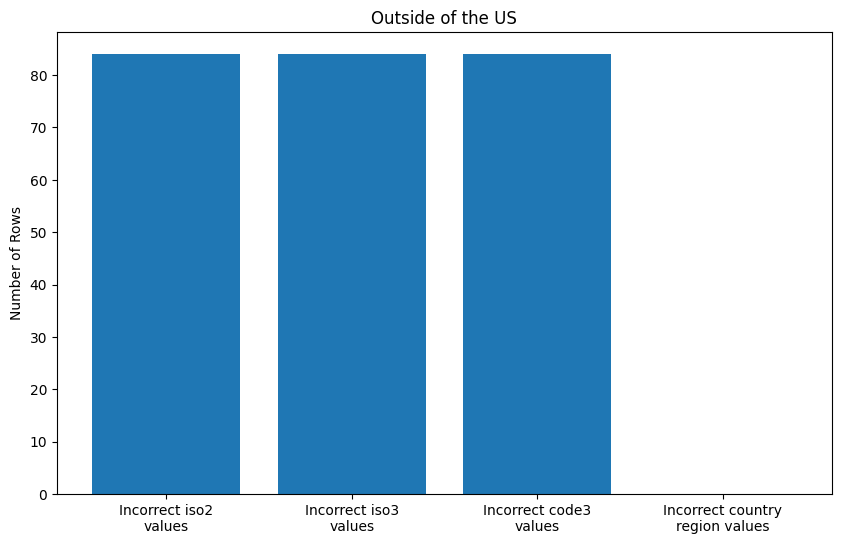

*** picosat: out of memory in 'new'


Retrieving notices: ...working... done
Solving environment: ...working... failed with initial frozen solve. Retrying with flexible solve.
Solving environment: ...working... failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: ...working... 


In [132]:
x = ["Incorrect iso2\nvalues", "Incorrect iso3\nvalues", "Incorrect code3\nvalues", "Incorrect country\nregion values"]
y = [len(incorrect_iso2), len(incorrect_iso3), len(incorrect_code3), len(incorrect_country)]

plt.figure(figsize=(10, 6))
plt.bar(x,y)
plt.ylabel("Number of Rows")
plt.title("Outside of the US")
plt.show()

In [42]:
# Get names of provinces/states not in US
no_us = covid19_deaths[covid19_deaths['iso2'] != 'US']
no_us['Province_State'].unique()

array(['American Samoa', 'Guam', 'Northern Mariana Islands',
       'Puerto Rico', 'Virgin Islands'], dtype=object)

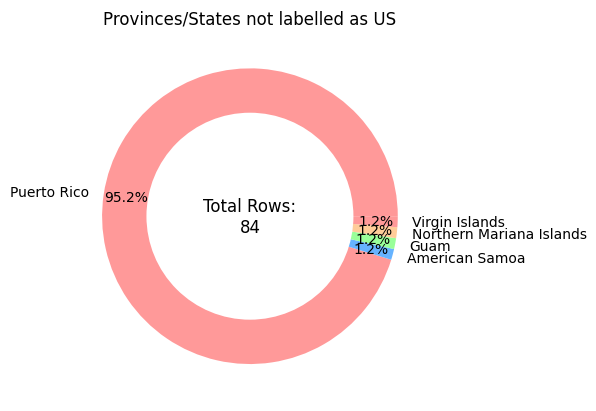

In [47]:
# data in US vs. not
labels = ['Puerto Rico', 'American Samoa', 'Guam', 'Northern Mariana Islands', 'Virgin Islands']
sizes = [len(covid19_deaths[(covid19_deaths['iso2'] != 'US') & (covid19_deaths['Province_State'] == 'Puerto Rico')]),
         len(covid19_deaths[(covid19_deaths['iso2'] != 'US') & (covid19_deaths['Province_State'] == 'American Samoa')]),
         len(covid19_deaths[(covid19_deaths['iso2'] != 'US') & (covid19_deaths['Province_State'] == 'Guam')]),
         len(covid19_deaths[(covid19_deaths['iso2'] != 'US') & (covid19_deaths['Province_State'] == 'Northern Mariana Islands')]),
         len(covid19_deaths[(covid19_deaths['iso2'] != 'US') & (covid19_deaths['Province_State'] == 'Virgin Islands')])]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

# Donut Chart - Adapted from a tutorial from GeeksforGeeks
plt.pie(sizes, colors=colors, labels=labels,
        autopct='%1.1f%%', pctdistance=0.85)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.text(0, 0, f'Total Rows:\n{len(no_us)}', 
         ha='center', va='center', fontsize=12)

plt.title('Provinces/States not labelled as US')
plt.show()

In [60]:
import numpy as np

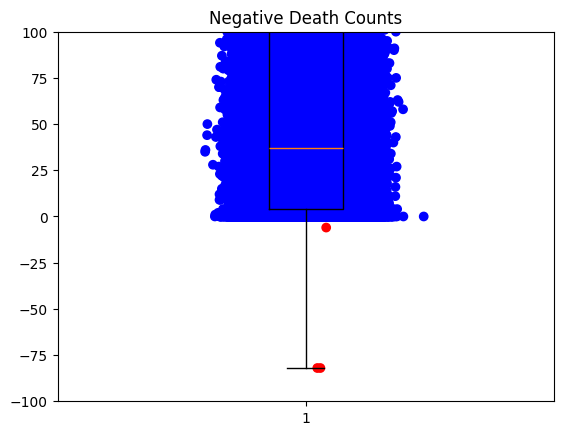

In [64]:
# negative death dates
values = covid19_deaths[death_columns].values.flatten()
x_jitter = np.random.normal(1, 0.04, size=len(values))
colors = np.where(values < 0, 'red', 'blue')

plt.boxplot(values)
plt.title('Negative Death Counts')
plt.scatter(x_jitter, values, c = colors)
plt.ylim(-100,100)
plt.show()

**Considerations for completeness:**
- Incorrect iso2, iso3, code3 values for rows corresponding to territories.
- Instances of 3 negative death counts. 

In [73]:
#CONCORDANCE - expected values?

#check cumulative death count does not decrease over time 
#calculate the change from day to day across date columns 
day2day_change = covid19_deaths[death_columns].diff(axis = 1)
#create a boolean (True if the death count went down that day)
decrease_count = day2day_change < 0
#count how many values were True 
decreases = decrease_count.values.sum()
print(f"Number of times death count decreased: {decreases}")
#find which counties and dates had decreasing death counts
negative_change = day2day_change < 0
rows_with_decreases = negative_change.any(axis = 1)
print(covid19_deaths[rows_with_decreases][['Admin2', 'Province_State']])
print()

#no deaths recorded before COVID existed (2020)
#Reference: https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
before_COVID = [column for column in death_columns if pd.to_datetime(column).year < 2020]
if len(before_COVID) > 0:
    deaths_before_COVID= (covid19_deaths[before_COVID] > 0).values.sum()
    print(f"Death counts before 2020: {deaths_before_COVID}")
else:
    print("No death counts before 2020")

#check that deaths at end of 2021 are higher or equal to deaths at the start of year, since that is the year of interest  
#find only 2021 columns 
death_columns_2021 =  list(covid19_deaths.filter(regex='/21$').columns)
start_2021 = death_columns_2021[0]
#last date of 2021
end_2021 = death_columns_2021[-1]
#find counties where total death count at the end of 2021 is less than those at the start of the year 
invalid_death_count_2021 = (covid19_deaths[end_2021] < covid19_deaths[start_2021]).sum()
print(f"Counties where end of 2021 death count is less than at the start of 2021: {invalid_death_count_2021}")

#get the last date of 2020 to get all of 2021
death_columns_2020 = list(covid19_deaths.filter(regex='/20$').columns)
#last date of 2020
end_2020 = death_columns_2020[-1]
#subtract end of 2020 from end of 2021 to get all 2021 deaths
deaths_2021_only = covid19_deaths[end_2021] - covid19_deaths[end_2020]
# check if 2021 deaths were higher than the population of a county
higher_death_count = (deaths_2021_only > covid19_deaths['Population']).sum()
print(f"Counties where death count is higher than its population (2021): {higher_death_count}")

Number of times death count decreased: 13732
          Admin2 Province_State
0        Autauga        Alabama
1        Baldwin        Alabama
2        Barbour        Alabama
3           Bibb        Alabama
4         Blount        Alabama
...          ...            ...
3332        Park        Wyoming
3334    Sheridan        Wyoming
3337       Teton        Wyoming
3339  Unassigned        Wyoming
3341      Weston        Wyoming

[2317 rows x 2 columns]

No death counts before 2020
Counties where end of 2021 death count is less than at the start of 2021: 15
Counties where death count is higher than its population (2021): 33


### Visualizations for Concordance

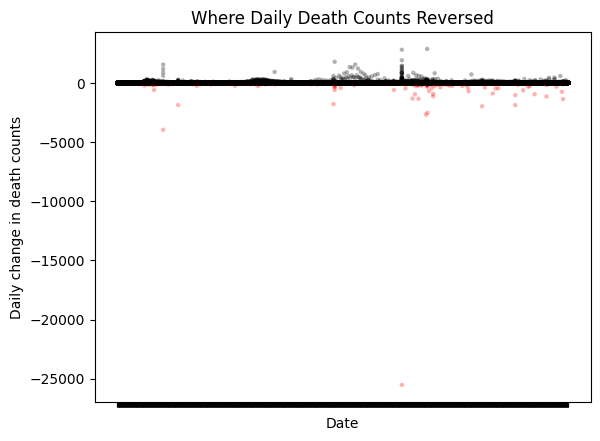

In [134]:
# death count reverses
day2day_change['UID'] = covid19_deaths['UID']

plot_df = day2day_change.melt(id_vars=['UID'], 
                              var_name='Date', 
                              value_name='Daily_Deaths')
colors = np.where(plot_df['Daily_Deaths'] < 0, 'red', 'black')
plt.scatter(plot_df['Date'], plot_df['Daily_Deaths'], 
            c=colors, alpha=0.3, s=10, lw=0)
plt.ylabel("Daily change in death counts")
plt.xlabel("Date")
plt.title("Where Daily Death Counts Reversed")
plt.gca().set_xticklabels([])
plt.show()

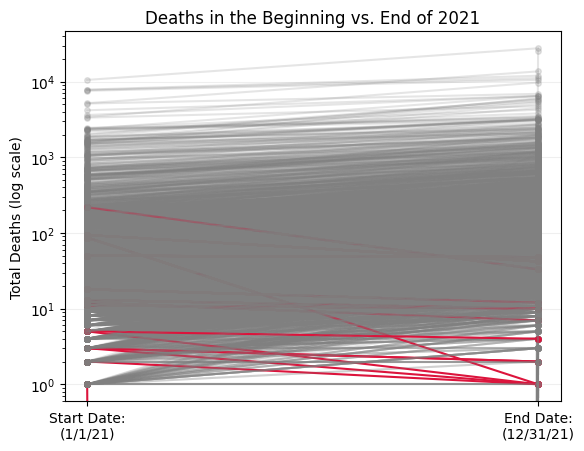

In [92]:
# Death count is too high
start_date = death_columns_2021[0]
end_date = death_columns_2021[-1]

for index, row in covid19_deaths.iterrows():
    y_values = [row[start_date], row[end_date]]
    x_values = [0, 1]
    diff = row[end_date] - row[start_date]
    line_color = 'crimson' if diff < 0 else 'grey'
    alpha = 1 if diff < 0 else 0.2
    plt.plot(x_values, y_values, '-o', color=line_color, alpha=alpha, markersize=4)
    
plt.xticks([0, 1], [f'Start Date:\n({start_date})', f'End Date:\n({end_date})'])

plt.title('Deaths in the Beginning vs. End of 2021')
plt.ylabel('Total Deaths (log scale)')
plt.grid(axis='y', alpha=0.2)
plt.yscale('log')

plt.show()

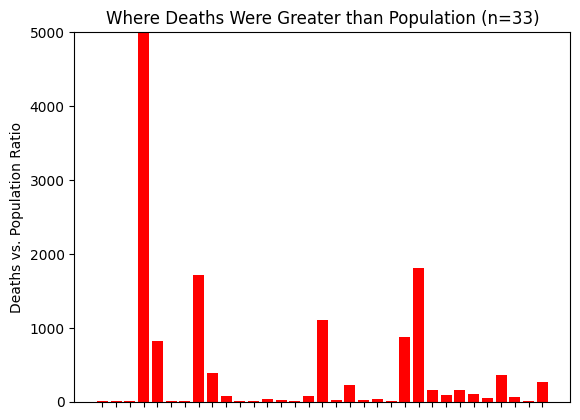

In [136]:
# Higher deaths than population
higher_death_count_cols = (deaths_2021_only > covid19_deaths['Population'])
x = covid19_deaths.loc[higher_death_count_cols, 'UID'].astype(str)
y1 = covid19_deaths.loc[higher_death_count_cols, 'Population']
y2 = deaths_2021_only.loc[higher_death_count_cols]

plt.bar(x, y2, color='red', label='2021 Deaths')
plt.bar(x, y1, color='lightgray', label='Population')
plt.ylim(0,5000)
plt.ylabel("Deaths vs. Population Ratio")
plt.title("Where Deaths Were Greater than Population (n=33)")
plt.gca().set_xticklabels([])

plt.show()

**Considerations for concordance:**
- Death counts decreased: were there notes about corrections to the data or an explanation for this?
- Instances of fewer death counts at the end of 2021 than at the end of 2021. Is this related to the death counts decreasing?
- Instances of higher death counts than county population in 2021.

In [138]:
#PLAUSIBILITY - do values make sense in real world application?
latest_date = covid19_deaths.columns[-1]
#find any county with total deaths over 100,000
high_deaths = covid19_deaths[covid19_deaths[latest_date] > 100000]
print("Counties with more than 100,000 deaths:")
print(high_deaths[['Admin2', 'Province_State', latest_date]])
print()

#check the population value is not zero or negative
invalid_population = (covid19_deaths['Population'] <= 0).sum()
print(f"Counties with zero or negative population values: {invalid_population}")
print()

#calculate death rate
#exclude rows with zero or missing population to avoid dividing by zero
valid_counties = covid19_deaths[covid19_deaths['Population'] > 0]
#calculate death rate using only valid counties
death_rate = (valid_counties[latest_date] / valid_counties['Population']) * 100
#find counties with death rates above 5% 
high_death_rate = (death_rate > 5).sum()
print(f"Counties with death rate above 5%: {high_death_rate}")
#print counties
print(valid_counties[death_rate > 5][['Admin2', 'Province_State', latest_date, 'Population']])

Counties with more than 100,000 deaths:
Empty DataFrame
Columns: [Admin2, Province_State, 3/9/23]
Index: []

Counties with zero or negative population values: 115

Counties with death rate above 5%: 0
Empty DataFrame
Columns: [Admin2, Province_State, 3/9/23, Population]
Index: []


### Visualizations for Plausibility

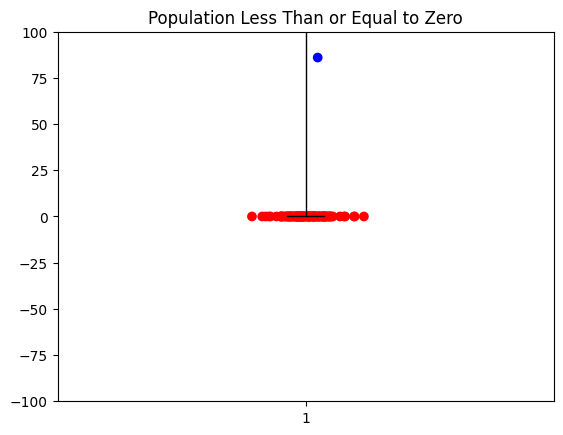

In [141]:
# population of zero
values = covid19_deaths['Population']
x_jitter = np.random.normal(1, 0.04, size=len(values))
colors = np.where(values <= 0, 'red', 'blue')

plt.boxplot(values)
plt.title('Population Less Than or Equal to Zero')
plt.scatter(x_jitter, values, c = colors)
plt.ylim(-100,100)
plt.show()

**Considerations for plausibility:**
- Instances of counties with zero or negative population values: are these associated with unassiagned counties?

In [255]:
#CURRENCY - data up to date for all of 2021?

#get the first and last date in the dataset
first_date = pd.to_datetime(death_columns[0])
last_date = pd.to_datetime(death_columns[-1])
#every date that should exist between first and last date
expected_dates_all = pd.date_range(start = first_date, end = last_date, freq='D')
#convert all date columns to datetime for comparison
actual_dates_all = pd.to_datetime(death_columns)
# find any dates that are missing
missing_dates_all = expected_dates_all.difference(actual_dates_all)
print(f"Dataset date range: {first_date.date()} to {last_date.date()}")
print(f"Number of expected dates: {len(expected_dates_all)}")
print(f"Number of dates in dataset: {len(actual_dates_all)}")
print(f"Number of missing dates: {len(missing_dates_all)}")
print()


#check when each state stopped reporting/ did that data vary?
#add up all county deaths for each state (by day)
state_totals = covid19_deaths.groupby('Province_State')[death_columns].sum()
#day to day change for each state
state_day2day_change = state_totals.diff(axis = 1)
#find the last date when death count changed (by state)
def find_last_update(row):
    updates = row[row > 0]
    #if nothing is found
    if len(updates) == 0:
        return "No update"
    #return last date 
    return updates.index[-1]
#apply function to each state 
last_update = state_day2day_change.apply(find_last_update, axis = 1)
print(last_update.sort_values())

Dataset date range: 2020-01-22 to 2023-03-09
Number of expected dates: 1143
Number of dates in dataset: 1143
Number of missing dates: 0

Province_State
Northern Mariana Islands    11/1/2022
Virgin Islands              2/13/2023
Alaska                      2/21/2023
Guam                        2/21/2023
Washington                   3/1/2023
Delaware                     3/1/2023
West Virginia                3/3/2023
Montana                      3/3/2023
Florida                      3/3/2023
Wyoming                      3/7/2023
Michigan                     3/7/2023
South Carolina               3/7/2023
Virginia                     3/7/2023
Maine                        3/7/2023
Pennsylvania                 3/8/2023
Oregon                       3/8/2023
South Dakota                 3/8/2023
Tennessee                    3/8/2023
North Carolina               3/8/2023
Nevada                       3/8/2023
Vermont                      3/8/2023
Louisiana                    3/8/2023
Alabama     

**Considerations for currency:**
- Why did certain states/territories stop recording death counts before 2023? 